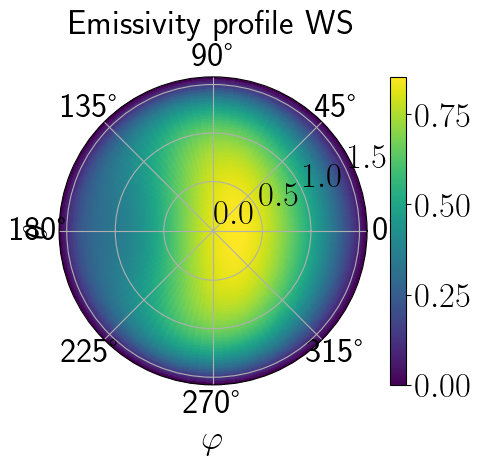

In [11]:
import numpy as np
import matplotlib.pyplot as plt

def profile_spherical_function_plotter(dpi_theta, dpi_phi, f): 
    theta_values = np.linspace(0, np.pi/2, dpi_theta)
    phi_values = np.linspace(0, 2*np.pi, dpi_phi)
    THETA, PHI = np.meshgrid(theta_values, phi_values)
    E_VALUES = np.zeros_like(THETA)
    for i in range(len(phi_values)):
        for j in range(len(theta_values)):
            E_VALUES[i, j] = f(theta_values[j], phi_values[i])  

    plt.figure(figsize = (6,4), dpi = 100)
    ax = plt.subplot(111, projection='polar')   
    c = ax.pcolormesh(PHI, THETA, E_VALUES, shading='auto')
    plt.colorbar(c, ax=ax)
    plt.title("Emissivity profile WS")
    plt.xlabel(r'$\varphi$')
    plt.ylabel(r'$\theta$')
    plt.show()

def Rp(theta, phi):
    c = 3*10**8
    w = 1.8 * 10**6 #(symbolic)
    n = 1
    ed = 9 + 0.3j
    exz = 9j
    ev = ed - abs(exz)**2/ed

    k0 = n*w/c
    kx, ky, kz0 = k0*np.sin(theta)*np.cos(phi), k0*np.sin(theta)*np.sin(phi), k0*np.cos(theta)
    kz1 = np.sqrt(ev * k0**2 - kx**2)
    
    r = (kz0 * ev - kz1 + kx*exz/ed)/(kz0 * ev + kz1 - kx*exz/ed)
    return abs(r)**2

def a(theta, phi):
    return 1 - Rp(theta, phi)

def e(theta, phi):
    return a(-theta, phi)

profile_spherical_function_plotter(dpi_theta = 100, dpi_phi = 100, f = e)